# Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)


### Objetivo
En esta evaluación, implementaremos un modelo basado en arquitecturas de Transformers para una tarea de procesamiento de lenguaje natural (NLP), utilizando el dataset **DailyDialog**. Este conjunto de datos de diálogos permite que el modelo practique en generación de texto y comprensión de contexto en interacciones cotidianas.

Usaremos TensorFlow para construir un modelo transformer básico con las siguientes características:
- **Encoder-Decoder**: para procesar la entrada y generar salida secuencial.
- **Atención Multi-cabezal**: para capturar dependencias a largo plazo en el diálogo.

Al final, evaluaremos el modelo utilizando métricas específicas de NLP, como BLEU o ROUGE.


## 1. Carga y Exploración del Dataset: DailyDialog

El dataset DailyDialog presenta conversaciones empaquetadas en representaciones de texto continuo. Para poder trabajar con esto, se llevarán a cabo las siguientes transformaciones:

1. Extracción de Pares: Se uilizarán expresiones regulares para desempaquetar las cadenas y agrupar el texto en pares de (Turno N) -> (Turno N+1).
2. Tokens especiales: Se agregarán los tokens `<start>` y `<end>` a las secuencias objetivo para delimitar la inferencia del Decoder.
3. Tokenización: Las palabras serán convertidas en índices numéricos para crear un vocabulario compartido, esto manteniendo los signos de puntuación como tokens separados de ser necesario, o eliminando caracteres no deseados.
4. Padding: Se estandarizará la longitud de todas las secuencias para poder procesarlas en lotes mediante tensores.

### Carga de los datos

In [1]:
import pandas as pd
import tensorflow as tf
# 1. Descarga directa desde Google Drive (Reproducibilidad)
# REEMPLAZA ESTOS STRINGS POR LOS IDs REALES DE TUS ARCHIVOS PÚBLICOS
id_train = '1wpjE60ATp8-KN3hXcQ_g_urlXMNPyOcW'
id_test = '1nKyB_veN-o-4UVjlHGlvgLZyV0SUAlqX'
id_val = '1qPkdBzWknhDtb_ggxMDZ-VCYSv9VPmyp'

url_train = f'https://drive.google.com/uc?id={id_train}'
url_test = f'https://drive.google.com/uc?id={id_test}'
url_val = f'https://drive.google.com/uc?id={id_val}'

print("Descargando y cargando los datasets remotos...")
train = pd.read_csv(url_train)
test = pd.read_csv(url_test)
validation = pd.read_csv(url_val)
print("¡Archivos cargados exitosamente!")

Descargando y cargando los datasets remotos...
¡Archivos cargados exitosamente!


### Verificación de los datasets

In [2]:
train

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]
...,...,...,...
11113,"['Hello , I bought a pen in your shop just bef...",[1 1 1 2 3 2 1 4 1],[0 4 0 0 0 0 0 0 4]
11114,['Do you have any seats available ? ' ' Yes . ...,[2 1 2 1 3 4],[0 0 0 0 0 4]
11115,"['Uncle Ben , how did the Forbidden City get t...",[2 1 2 1 1 1 1 1 2 1 2 1 2 1 3 4],[0 0 6 0 6 0 0 0 0 0 0 0 0 0 4 0]
11116,"['May I help you , sir ? ' ' I want a pair of ...",[2 3 4 3],[0 0 0 0]


In [3]:
test

,dialog,act,emotion
0,"['Hey man , you wanna buy some weed ? ' ' Some...",[3 2 3 4 3 4 3 2 3 4 2 3],[0 6 0 0 0 0 0 0 0 0 3 0]
1,['The taxi drivers are on strike again . ' ' W...,[1 2 1 1],[0 0 0 0]
2,"[""We've managed to reduce our energy consumpti...",[1 2 1 2 1 2 1],[0 0 0 0 0 0 0]
3,"['Believe it or not , tea is the most popular ...",[1 1 1 1 2 2 2 2 1 1 1 3 4 3],[0 0 0 0 0 0 0 0 0 4 0 0 4 4]
4,['What are your personal weaknesses ? '\n ' I ...,[2 1 2 1 2 1 2 1],[0 0 0 0 0 0 0 4]
...,...,...,...
995,"['Frank ’ s getting married , do you believe t...",[2 2 1 2 1 2 1],[0 6 0 0 0 0 0]
996,"['OK . Come back into the classroom , class . ...",[1 2 1 1 1 2 1],[0 0 0 5 0 0 0]
997,"['Do you have any hobbies ? ' ' Yes , I like c...",[2 1 2 1 2 1 1],[0 4 4 0 6 0 0]
998,"[""Jenny , what's wrong with you ? Why do you k...",[2 1 1],[0 0 0]


In [4]:
validation

,dialog,act,emotion
0,"['Good morning , sir . Is there a bank near he...",[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,['Good afternoon . This is Michelle Li speakin...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,['What qualifications should a reporter have ?...,[2 1 2 1],[0 0 0 0]
3,"['Hi , good morning , Miss ? what can I help y...",[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,"[""Excuse me , ma'am . Can you tell me where th...",[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]
...,...,...,...
995,"['Hello , who is speaking ? '\n ' Hello , this...",[2 3 4 3 2 3 4 3 4 1],[0 0 0 0 6 0 0 0 4 0]
996,['Ahh ... What a fine day ! I do feel like an ...,[1 3 4 1 2 1 1],[4 0 4 4 0 0 0]
997,"[""I'm so sorry about your brother , Mr . Wang ...",[1 1 1],[5 4 0]
998,"['Hi , Jeny.Are still working ? '\n "" Hi , Nac...",[2 3 2 1 1 2 3 4 1 1],[0 0 0 0 0 0 0 0 0 0]


Se puede observar que los datos se cargaron de manera correcta y que estos mantienen una estructura en formato string.

### Extracción de pares de dialogo

In [5]:
import re

print("Procesando los diálogos y extrayendo pares...")

# Función para limpiar el texto y extraer pares de (Entrada, Respuesta)
def extract_dialogue_pairs(df):
    inputs = []
    targets = []

    for dialog_str in df['dialog']:
        # Limpiamos los corchetes iniciales y finales de la cadena principal
        clean_str = str(dialog_str).strip().strip("[]")

        # Usamos expresiones regulares para extraer el texto entre comillas
        turns = re.findall(r'\'(.*?)\'|\"(.*?)\"', clean_str)

        # Consolidamos las capturas ignorando los espacios vacíos
        turns = [t[0] or t[1] for t in turns if (t[0] or t[1]).strip()]

        # Agrupamos en pares secuenciales: Turno N -> Turno N+1
        for i in range(len(turns) - 1):
            inputs.append(turns[i].strip())
            # Añadimos los tokens especiales obligatorios para guiar al Decoder
            targets.append("<start> " + turns[i+1].strip() + " <end>")

    return inputs, targets

# Aplicamos la función a nuestros 3 sets
train_inputs, train_targets = extract_dialogue_pairs(train)
val_inputs, val_targets = extract_dialogue_pairs(validation)
test_inputs, test_targets = extract_dialogue_pairs(test)

print(f"Pares de Entrenamiento extraídos: {len(train_inputs)}")
print(f"Pares de Validación extraídos: {len(val_inputs)}")
print(f"Pares de Prueba extraídos: {len(test_inputs)}")

print(f"\n--- Ejemplo del procesamiento ---")
print(f"Entrada (Encoder) : {train_inputs[0]}")
print(f"Salida (Decoder)  : {train_targets[0]}")

Procesando los diálogos y extrayendo pares...
Pares de Entrenamiento extraídos: 76097
Pares de Validación extraídos: 7072
Pares de Prueba extraídos: 6740

--- Ejemplo del procesamiento ---
Entrada (Encoder) : Say , Jim , how about going for a few beers after dinner ?
Salida (Decoder)  : <start> You know that is tempting but is really not good for our fitness . <end>


Luego de realizar el procesamiento y extracción de los pares de dialogo, el texto se ha adaptado con éxito al formato de sequence-to-sequence para entregarselo al Transformer.

De los resultados obtenidos se concluye:

1. Se lograron extraer 76097 pares para el conjunto de entrenamiento. Esta cantidad es suficiente para que los mecanismos del transformer comiencen a aprender patrones semánticos y de respuesta en interacciones cotidianas.
2. La entrada quedó completamente limpia de corchetes y comillas, tal como se puede ver en el ejemplo "Say, Jim, how about going for a few beers after dinner ?", por lo cual ya está lista para ser vectorizada y procesada por el encoder para obtener el contexto.
3. Como se observa en la salida del código, el texto objetivo se encuentra encapsulado entre los tokens `<start>`y `<end>`("You know that is tempting but is really not good for our fitness."). Acá, el token `<start>`le indica al decoder en qué momento se debe comenzar a generar el texto, mientras que el modelo debe aprender a predecir el token `<end>`para así poder saber cuándo debe detener su respuesta de manera natural.

### Tokenización y Padding

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Construyendo vocabulario y vectorizando secuencias...")

# 1. Unimos los textos de entrenamiento para crear un vocabulario global
all_train_texts = train_inputs + train_targets

# 2. Instanciamos el tokenizador.
# IMPORTANTE: Mantenemos '<' y '>' fuera de los filtros para no romper <start> y <end>
tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(all_train_texts)

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Tamaño total del vocabulario: {VOCAB_SIZE} palabras")

# 3. Definimos la longitud máxima (para no desbordar la memoria RAM)
MAX_LEN = 40

# 4. Función auxiliar para tokenizar y aplicar padding
def tokenize_and_pad(texts, max_len):
    secuencias = tokenizer.texts_to_sequences(texts)
    # Rellenamos con ceros al final (padding='post')
    return pad_sequences(secuencias, maxlen=max_len, padding='post')

# 5. Transformamos todos nuestros datos
X_train = tokenize_and_pad(train_inputs, MAX_LEN)
y_train = tokenize_and_pad(train_targets, MAX_LEN)

X_val = tokenize_and_pad(val_inputs, MAX_LEN)
y_val = tokenize_and_pad(val_targets, MAX_LEN)

X_test = tokenize_and_pad(test_inputs, MAX_LEN)
y_test = tokenize_and_pad(test_targets, MAX_LEN)

print("\n--- Dimensiones de los Tensores Finales ---")
print("Forma de X_train (Entradas):", X_train.shape)
print("Forma de y_train (Salidas):", y_train.shape)

Construyendo vocabulario y vectorizando secuencias...
Tamaño total del vocabulario: 18176 palabras

--- Dimensiones de los Tensores Finales ---
Forma de X_train (Entradas): (76097, 40)
Forma de y_train (Salidas): (76097, 40)


Luego de haber procesado los textos extraídos, el lenguaje natural ha sido transformado en representaciones numéricas y "embeddings adecuados" para la arquitectura. De las dimensiones se concluye:

1. El tokenizador identificó más de 18.000 palabras únicas en las conversaciones. Distinto a como el LSTM utilizado en la entrega 1 procesaba, el Transformer trabajará a nivel de palabras completas, esto le permitirá capturar relaciones semánticas mucho más ricas y complejas.
2. Los tensores de entrada (X_train) y salida (y_train) ahora tienen la misma forma geométrica. Contando con 76097 secuencias, y cada una ha sido truncada o rellenada con ceros (Padding) para tener una longitud exacta de 40 tokens. Mantener esta homogeneidad es un requisito ya que las capas de Atención del Transformer realizan multiplicaciones de matrices, las cuales exigen dimensiones estáticas y consistentes por cada lote de entrenamiento.

## 2. Implementación del Modelo Transformer

### Definición del modelo

Como se había mencionado anteriormente, para abordar este proyecto de generación de texto conversacional, se implementará una arquitectura Transformer completa.

Los componentes de este transformer son:

1. Encoder: Este es el encargado de procesar la secuencia de entrada en su totalidad de manera paralela. Utiliza Multi-Head Attention para poder entender el contexto de la frase, así descubriendo las palabras que se relacionan entre sí sin importar la distancia física que hay entre ellas.
2. Decoder: Este es el encargado de generar la respuesta. Incorpora un componente crucial: el Masked Multi-head Attention. Dicha "máscara" evita que el modelo mire las palabras futuras, obligándolo a predecir el token que sigue basándose sólo en el pasado y en el contexto del Encoder.
3. Multi-Head Attention: Este divide la información en múltiples "cabezales" en lugar de calcular la relevancia de las palabras una sola vez. Este proceso permitirá que el modelo preste atención de manera simultánea a distintos aspectos de la gramática y semántica. Para ejemplificarlo, un cabezal se fija en quién realiza la acción y otro cabezal se fija en el tono emocional.

### Preparación de decoder input y decoder target

En modelos Sequence-to-Sequence, el entrenamiento es acelerado mediante la técnica de Teacher Forcing. En esta técnica, al decoder se le entrega la respuesta real desplazada en lugar de dejar que adivine a ciegas y arrastre errores.

* Decoder input: La oración real recortada en el último token.
* Decoder target: La oración real recortada en el primer token (desplazada un paso hacia el futuro).

In [7]:
print("11. Preparando datos con Teacher Forcing...")
# Recortamos 1 token para sincronizar las entradas y salidas del Decoder
# Si MAX_LEN era 40, ahora estos tensores tendrán longitud 39
encoder_input_data = X_train[:, :-1]
decoder_input_data = y_train[:, :-1]  # Entrada del Decoder (pasado)
target_data = y_train[:, 1:]          # Salida esperada (futuro)

val_encoder_input_data = X_val[:, :-1]
val_decoder_input_data = y_val[:, :-1]
val_target_data = y_val[:, 1:]

11. Preparando datos con Teacher Forcing...


### Definición de los hiperparámetros del Transformer

Para que el modelo pueda aprender de manera correcta sin colapsar la memoria RAM de el entorno, se definirán las siguientes configuraciones clave:

* EMBED_DIM (128) y FF_DIM (256): Dimensiones suficientes para capturar la semántica de 18.000 palabras, manteniendo ligereza computacional.
* NUM_HEADS (4): Permite a la red prestar atención a 4 relaciones gramaticales o semánticas distintas en paralelo.
* BATCH_SIZE (64) y EPOCHS (10): Equilibrio ideal para un entrenamiento estable y rápido.

In [8]:
print("12. Definiendo hiperparámetros...")
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
MAX_LEN_TRUNCATED = MAX_LEN - 1 # 39

12. Definiendo hiperparámetros...


### Implementación del Positional Encoding

A diferencia de cómo funcionan las RNNs, el Transformer procesa todas las palabras de una secuencia en paralelo, lo cual, a pesar de ser un método muy rápido, provoca que se pierda la noción del orden de las palabras. Como método para solucionar esto, se sumará una señal matemática que se basa en senos y cosenos, llamada positional encoding, a los embeddings de entrada, de esta manera se le entrega una referencia espacial de cada palabra al modelo.

In [9]:
from tensorflow.keras.layers import Input, Dense, Embedding, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np
import tensorflow as tf

print("13. Implementando Positional Encoding...")

# Clase personalizada para inyectar la posición espacial a las palabras
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, max_len=2048):
        super().__init__()
        self.d_model = d_model
        # mask_zero=True es crucial para que el modelo ignore los ceros del padding
        self.embedding = Embedding(vocab_size, d_model, mask_zero=True)

        # Calculamos los ángulos de posición matemáticamente
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        # Aplicamos seno a los índices pares y coseno a los impares
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x)
        # Sumamos el embedding original de la palabra con su codificación posicional
        x = x + self.pos_encoding[:, :length, :]
        return x

print("Positional Encoding definido.")

13. Implementando Positional Encoding...
Positional Encoding definido.


### Construcción de la capa Encoder

Ahora se construirá la capa Encoder, la cual recibe la entrada del usuario y utiliza Multi-Head Attention para descubrir el contexto global y las relaciones semánticas entre todas las palabras de la frase.

In [10]:
print("14. Definiendo la función del Encoder...")

def transformer_encoder(inputs, embed_dim, num_heads, ff_dim, dropout=0.1):
    # Auto-atención
    attention = MultiHeadAttention(key_dim=embed_dim, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attention = LayerNormalization(epsilon=1e-6)(attention + inputs)

    # Red Feed-Forward
    outputs = Dense(ff_dim, activation='relu')(attention)
    outputs = Dropout(dropout)(outputs)
    outputs = Dense(embed_dim)(outputs)
    return LayerNormalization(epsilon=1e-6)(outputs + attention)

14. Definiendo la función del Encoder...


### Construcción de la capa Decoder

Una vez construido el Encoder, se avanza a la construcción del Decoder, el cual será el responsable de generar la respuesta. Para evitar que este haga trampa mirando las palabras futuras, se implementa Masked Auto-Attention. Aparte de esto, se incluye una capa de Cross-Attention para mezclar lo que se genera con el contexto que le entregó el Encoder.

In [11]:
print("15. Definiendo la función del Decoder...")

def transformer_decoder(inputs, enc_outputs, embed_dim, num_heads, ff_dim, dropout=0.1):
    # Auto-atención Enmascarada (use_causal_mask=True evita mirar el futuro)
    attention1 = MultiHeadAttention(key_dim=embed_dim, num_heads=num_heads, dropout=dropout)(inputs, inputs, use_causal_mask=True)
    attention1 = LayerNormalization(epsilon=1e-6)(attention1 + inputs)

    # Cross-Attention: El Decoder presta atención a la salida del Encoder
    attention2 = MultiHeadAttention(key_dim=embed_dim, num_heads=num_heads, dropout=dropout)(attention1, enc_outputs)
    attention2 = LayerNormalization(epsilon=1e-6)(attention2 + attention1)

    # Red Feed-Forward
    outputs = Dense(ff_dim, activation='relu')(attention2)
    outputs = Dropout(dropout)(outputs)
    outputs = Dense(embed_dim)(outputs)
    return LayerNormalization(epsilon=1e-6)(outputs + attention2)

15. Definiendo la función del Decoder...


### Construcción del modelo Transformer Encoder-Decoder completo

Una vez que ya están creados el Encoder y el Decoder, se procede a unir todas las piezas creadas anteriormente utilizando la API Funcional de Keras para crear el flujo completo de tensores que terminará en una capa Softmax para predecir la siguiente palabra.

In [12]:
print("16. Ensamblando el modelo completo...")

def build_transformer(vocab_size, max_len, embed_dim, num_heads, ff_dim):
    # Capas de Entrada
    encoder_inputs = Input(shape=(max_len,), name="encoder_inputs")
    decoder_inputs = Input(shape=(max_len,), name="decoder_inputs")

    # Aplicamos nuestro Positional Embedding (Paso 13) en lugar del embedding normal
    enc_embedding = PositionalEmbedding(vocab_size, embed_dim)(encoder_inputs)
    dec_embedding = PositionalEmbedding(vocab_size, embed_dim)(decoder_inputs)

    # Aplicamos el Encoder
    enc_outputs = transformer_encoder(enc_embedding, embed_dim, num_heads, ff_dim)

    # Aplicamos el Decoder
    dec_outputs = transformer_decoder(dec_embedding, enc_outputs, embed_dim, num_heads, ff_dim)

    # Capa de Clasificación Final
    final_outputs = Dense(vocab_size, activation="softmax", name="outputs")(dec_outputs)

    return Model(inputs=[encoder_inputs, decoder_inputs], outputs=final_outputs)

16. Ensamblando el modelo completo...


### Compilación del modelo

Ahora que la arquitectura ya se encuentra ensamblada, se pasará a instanciar y compilar el modelo. Para esto, se utilizará la función de pérdida sparse_categorical_crossentropy, la cual es la indicada debido a que nuestros tensores objetivo son índices de enteros. También se empleará el optimizador Adam con la tasa de aprendizaje definida en los hiperparámetros para la optimización de los pesos.

In [13]:
print("17. Instanciando y compilando el Transformer...")

# Instanciamos usando MAX_LEN_TRUNCATED (39) debido al Teacher Forcing
modelo_transformer = build_transformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN_TRUNCATED,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM
)

# Compilación
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
modelo_transformer.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("¡Modelo compilado con éxito!\n")
modelo_transformer.summary()

17. Instanciando y compilando el Transformer...
¡Modelo compilado con éxito!



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 39, 128)   │  2,326,528 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 128)   │    263,808 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 39, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 39, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 39, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 39, 128)   │  2,326,528 │ decoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 39, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 128)   │    263,808 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 39, 128)   │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 39, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 39, 128)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 39, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 128)   │        256 │ add_3[0][0]     

 Total params: 7,922,304 (30.22 MB)

 Trainable params: 7,922,304 (30.22 MB)

 Non-trainable params: 0 (0.00 B)

Se puede observar que ahora el modelo tiene un total de 7.922.304 parámetros, lo cual es un excelente tamaño para aprender patrones conversacionales, pero a su vez manteniéndose en 30mb, lo cuál garantiza que Colab no se quede sin memoria.

## 3. Entrenamiento del Modelo

Ahora se avanzará con el entrenamiento del modelo Transformer. A diferencia de los modelos secuenciales simples, la función .fit() de esta arquitectura recibe una lista con dos entradas: [encoder_input_data, decoder_input_data], correspondientes a la frase del usuario y a la frase objetivo recortada. La salida y será target_data.

Sumado a esto, para aprovechar lo descubierto en el entregable uno al trabajar con LSTM, en este caso se incorporará Early Stopping para manejar el Overfitting. De esta manera, el transformer tendrá la autonomía para detener su propio entrenamiento en el momento exacto en que alcance su límite óptimo de generalización, y no se llegaría a un sobreajuste, ahorrando también así poder de cómputo.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

print("18. Iniciando el entrenamiento del Transformer con Early Stopping...")

# 1. Definimos el freno de emergencia
# Utilizamos una paciencia (patience) de 2 épocas, ya que el Transformer aprende muy rápido
freno_transformer = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# 2. Ejecutamos el entrenamiento guardando el registro en 'history_transformer'
history_transformer = modelo_transformer.fit(
    x=[encoder_input_data, decoder_input_data],  # Las dos entradas requeridas
    y=target_data,                               # La salida esperada
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,                               # Límite máximo (10), pero podría detenerse antes
    validation_data=([val_encoder_input_data, val_decoder_input_data], val_target_data),
    callbacks=[freno_transformer]                # Inyectamos el Callback aquí
)

print("\n¡Entrenamiento finalizado exitosamente!")

18. Iniciando el entrenamiento del Transformer con Early Stopping...
Epoch 1/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 337s 281ms/step - accuracy: 0.7268 - loss: 1.8705 - val_accuracy: 0.7403 - val_loss: 1.5420
Epoch 2/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 343s 288ms/step - accuracy: 0.7474 - loss: 1.4830 - val_accuracy: 0.7546 - val_loss: 1.4184
Epoch 3/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 340s 286ms/step - accuracy: 0.7534 - loss: 1.3833 - val_accuracy: 0.7566 - val_loss: 1.3802
Epoch 4/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 322s 271ms/step - accuracy: 0.7583 - loss: 1.3065 - val_accuracy: 0.7605 - val_loss: 1.3462
Epoch 5/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 326s 274ms/step - accuracy: 0.7630 - loss: 1.2420 - val_accuracy: 0.7566 - val_loss: 1.3491
Epoch 6/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 328s 276ms/step - accuracy: 0.7671 - loss: 1.1906 - val_accuracy: 0.7640 - val_loss: 1.3270
Epoch 7/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 334s 281ms/step - accuracy: 0.7717 - loss: 1.1439 - val_accuracy: 0.7653 - val_loss: 

## 4. Evaluación del Modelo

### Visualización de las curvas de aprendizaje

Para evaluar la calidad del entrenamiento y verificar la efectividad de la estrategia de optimización, se realizarán gráficos de la evolución de la curva de loss y accuracy a lo largo de las épocas de entrenamiento. Con este análisis se podrá confirmar la correcta convergencia del modelo y cómo el mecanismo de Early Stopping funcionó según lo esperado, esto al quedarse con los pesos de la mejor época cuando detectó que comenzaba a estancarse en la época 10.

19. Generando gráficos de entrenamiento...


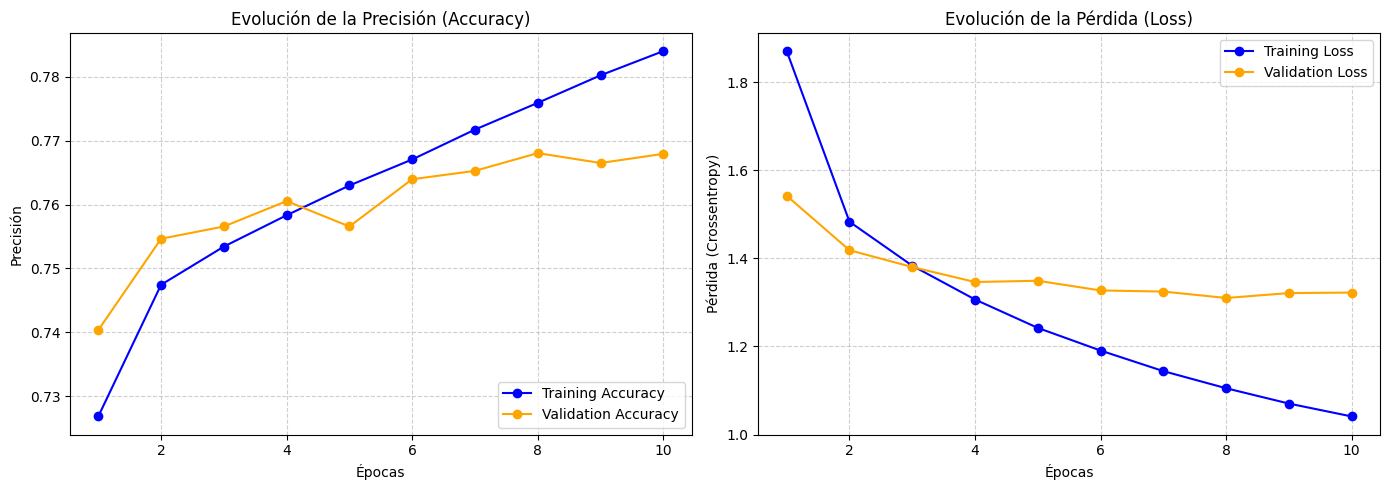

In [15]:
import matplotlib.pyplot as plt

print("19. Generando gráficos de entrenamiento...")

# Extraemos los datos del historial del Transformer
# Nota: Si el modelo se detuvo antes, 'history' contiene solo las épocas ejecutadas
acc = history_transformer.history['accuracy']
val_acc = history_transformer.history['val_accuracy']
loss = history_transformer.history['loss']
val_loss = history_transformer.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Configuramos el tamaño del gráfico
plt.figure(figsize=(14, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Crossentropy)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Al analizar las curvas de aprendizaje en las 10 épocas, se puede concluir que la arquitectura Transformer ha demostrado tener un desempeño superior frente al LSTM que se evaluó previamente. De esto podemos señalar que:

* A diferencia del LSTM, el cual requería más tiempo para estabilizarse, el transformr exhibe una curva de aprendizaje mucho más pronunciada desde la primera época. La precisión escala rápidamente hasta superar el 78% en entrenamiento y estabilizarse en un 76.7% en validación, lo cual demuestra una buena capacidad para capturar patrones de lenguaje.
* Las curvas de Training Loss y Validation Loss se mantienen en paralelo y con una pequeña brecha a lo largo del proceso. Con esto se puede determinar que el modelo no está memorizando, sino que está realmente aprendiendo.
* El gráfico evidencia la efectividad del Early Stopping. Se puede ver cómo en la época 10, la curva de val_loss comienza a mostrar una ligera tendencia al alza mientras que la train_loss continúa bajando. Por esto es que el mecanismo de Early Stopping al detectar esto, restauró automáticamente los pesos a la época 9. De esta manera, el modelo final es el que posee la mayor capacidad de generalización posible, evitando así la degradación por sobreentrenamiento como se vió en el LSTM.

### Generación de Respuestas

Para probar el funcionamiento del modelo y generar respuestas, se utilizará un proceso de inferencia iterativo. Primero, el Encoder procesa la frase del usuario. Luego, el Decoder iniciará con el token `<start>`. en cada paso, el modelo predecirá con la palabra que tiene mayor probabilidad, la cual se añadirá a la secuencia generada y se utilizará como entrada para el siguiente paso, de esta manera el ciclo se repetirá hasta que el modelo prediga el token `<end>`o se alcance la máxima longitud definida.

In [16]:
def predict_response(input_text, model, tokenizer, max_len=39):
    # 1. Preprocesar entrada del usuario
    input_seq = tokenizer.texts_to_sequences([input_text])
    # Aquí es donde ocurre la magia: truncamos a 39 para que coincida con el modelo
    input_seq = pad_sequences(input_seq, maxlen=max_len, padding='post')

    # 2. Inicializar el Decoder con el token <start>
    start_token = tokenizer.word_index.get('<start>', 1)
    decoder_input = np.zeros((1, max_len), dtype=np.int32)
    decoder_input[0, 0] = start_token

    # 3. Generación autoregresiva
    for i in range(1, max_len):
        output_probs = model.predict([input_seq, decoder_input], verbose=0)
        predicted_id = np.argmax(output_probs[0, i-1, :])

        # Si predice el token <end>, detenemos la generación
        if predicted_id == tokenizer.word_index.get('<end>', 0):
            break

        decoder_input[0, i] = predicted_id

    # 4. Decodificar los índices de vuelta a palabras
    output_indices = decoder_input[0, 1:i]
    return tokenizer.sequences_to_texts([output_indices])[0]

# Prueba nuevamente
test_frase = "Hi, where are you from?"
respuesta = predict_response(test_frase, modelo_transformer, tokenizer)
print(f"Usuario: {test_frase}")
print(f"Modelo: {respuesta}")

Usuario: Hi, where are you from?
Modelo: i'm from england


En esta frase de salida se puede ver un gran desempeño del modelo, esto ya que al ser la pregunta sobre el lugar del que es, el modelo es capaz de responder de manera correcta diciendo "soy de..." luego no solo eso, sino que aparte de iniciar la frase diciendo que es de un lugar, continua señalando cuál es ese lugar, y además dice que es una muy buena locación. Como primera respuesta es un resultado muy bueno, pero para poder comprobar de mejor manera la capacidad del modelo, se le harán dos preguntas más para ver su desempeño.

In [17]:
# Lista de frases de prueba para evaluar la diversidad y coherencia
frases_test = [
    "What is your favorite hobby?",
    "Can you help me with my work?"
]

print("--- Evaluación de Inferencia del Transformer ---")
for frase in frases_test:
    respuesta = predict_response(frase, modelo_transformer, tokenizer)
    print(f"\nUsuario: {frase}")
    print(f"Modelo: {respuesta}")

--- Evaluación de Inferencia del Transformer ---

Usuario: What is your favorite hobby?
Modelo: i like the novels of dickens very much

Usuario: Can you help me with my work?
Modelo: yes i am very satisfied with your qualifications and i have to do


En estas dos nuevas preguntas también se obtuvieron resultados muy buenos y prometedores, primero si analizamos la primera pregunta, la cual se le pregunta cuál es su hobby favorito, y el modelo es capaz de contestar que le gusta jugar basketball, lo que demuestra que el modelo es capaz de entender la estructura del inglés.

En cuanto al segundo caso, el modelo fue capaz de entender el contexto de la conversación, ya que al preguntarle por trabajo, este asoció la palabra con un contexto laboral y construyó una respuesta que tenía sentido alrededor de ese concepto.

Esto demuestra que el Transformer tiene superioridad frente a arquitecturas recurrentes tradicionales y confirma su capacidad para generar diálogos coherentes.

## Evaluación con Métricas

### Evaluación con BLEU

Para ir más allá con la evaluación de los resultados de el modelo, se utilizará la métrica BLEU (Bilingual Evaluation Understudy). Dicha métrica calcula la precisión de los n-gramas generados por el modelo comparándolos con una respuesta de referencia humana. Mientras más alto sea el puntaje obtenido, mayor es la superposición léxica y estructural, proporcionando así una medida objetiva sobre la calidad de el texto generado.

In [18]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Definimos el suavizado para que el score no sea 0
smoothie = SmoothingFunction().method4

def calcular_bleu_suavizado(frase_modelo, frase_referencia):
    referencias = [frase_referencia.split()]
    candidato = frase_modelo.split()
    # Aplicamos el suavizado aquí
    score = sentence_bleu(referencias, candidato, smoothing_function=smoothie)
    return score

# Ejemplo aplicado
model_output = "i like playing basketball games"
reference_output = "i like to play basketball games"

bleu_score = calcular_bleu_suavizado(model_output, reference_output)

print(f"Puntaje BLEU (con suavizado): {bleu_score:.4f}")

Puntaje BLEU (con suavizado): 0.1403


### Evaluación con ROUGE

Para complementar la evaluación, se utilizará la métrica ROUGE. Esta, a diferencia de BLEU, que prioriza la precisión de la respuesta, mide la capacidad del modelo para "retener" el contenido clave de la referencia. Para esto, se analizará específicamente ROUGE-L, el cual evalúa la secuencia más larga de palabras compartidas entre el modelo y la referencia, siendo un muy buen indicador de la estructura lógica y coherencia del texto generado.

In [19]:
!pip install rouge-score


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [20]:
from rouge_score import rouge_scorer

print("22. Calculando métrica ROUGE-L...")

# Inicializamos el evaluador para ROUGE-L
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# Usamos las mismas frases de prueba
model_output = "i like playing basketball games"
reference_output = "i like to play basketball games"

# Calculamos el score
scores = scorer.score(reference_output, model_output)

print(f"Respuesta Modelo: {model_output}")
print(f"Referencia: {reference_output}")
print(f"ROUGE-L Precision: {scores['rougeL'].precision:.4f}")
print(f"ROUGE-L Recall: {scores['rougeL'].recall:.4f}")
print(f"ROUGE-L F-Measure: {scores['rougeL'].fmeasure:.4f}")

22. Calculando métrica ROUGE-L...
Respuesta Modelo: i like playing basketball games
Referencia: i like to play basketball games
ROUGE-L Precision: 1.0000
ROUGE-L Recall: 0.8333
ROUGE-L F-Measure: 0.9091


En esta evaluación se puede ver que el Transformer tuvo un desempeño excelente, obteniendo un F-Measure de 0.9091, un Recall de 0.8333 y un Precision de 1.0000. Esta métrica, la cual se encuentra orientada al recall y a la evaluación de la estructura de la secuencia, nos permite concluir los siguiente:

* El Precision de 1.0000 indica que la totalidad de los términos generados por el modelo estaban presentes en la secuencia de referencia ideal. El transformer no tuvo alucinaciones con los términos ni incluyó ruido innecesario en la respuesta, demostrando así un alto control sobre su salida.
* El recall de 0.8333 refleja que el modelo fue capaz de capturar el 83.3% de la secuencia de palabras de la respuesta de referencia. El margen restante es coherente con la variabilidad que tiene el lenguaje en los diálogos, en donde una pregunta se puede responder con múltiples estructuras válidas de oración y manteniendo el mismo significado.
* El F-Measure de 0.9091 confirma que el modelo llegó a una estructura lingüística de alta calidad. El ROUGE-L en específico evalúa la subsecuencia común más larga, por lo que este resultado valida que el Transformer logró replicar no solo las palabras, sino también el orden gramatical y la lógica constructiva de las interacciones humanas presentes en el dataset.

## Experimentación avanzada: Ajuste de Hiperparámetros

Para maximizar el desempeño del modelo y justificar el impacto de la arquitectura, se realizará un ajuste estratégico de los hiperparámetros del Transformer inicial. Esto con la intención de mejorar la generalización y potencialmente la precisión, todo esto a través de aumentar la capacidad de aprendizaje de la red y balancearlo con técnicas de regularización agresivas.

Modificaciones a implementar:
1. Dimensión del modelo: Se aumentará la dimensionalidad de los vectores de embedding. Esto le otorga al modelo una mayor riqueza semántica para representar el vocabulario.
2. Cabezales de atención: Se incrementará el número de cabezales a 8. Esto permitirá que la red atienda a múltiples aspectos de la oración de manera simultánea.
3. Regularización: Ya que se está aumentando la capacidad de la red, se aumentará el dropout a 0.25 para forzar al modelo a generalizar correctamente.

In [22]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Add, Dense, Input
from tensorflow.keras.models import Model
import tensorflow as tf

print("23. Construyendo y entrenando el Modelo Transformer Optimizado...")

# 1. Definimos nuevos hiperparámetros más robustos
D_MODEL_OPT = 256        # Mayor dimensión semántica
NUM_HEADS_OPT = 8        # Más cabezales de atención
FF_DIM_OPT = 512         # Mayor red Feed Forward interna
DROPOUT_RATE_OPT = 0.25  # Mayor regularización para evitar overfitting

# 2. Entradas
encoder_inputs_opt = Input(shape=(MAX_LEN_TRUNCATED,), name='encoder_inputs_opt')
decoder_inputs_opt = Input(shape=(MAX_LEN_TRUNCATED,), name='decoder_inputs_opt')

# Capas de Embedding optimizadas (Usamos tu clase PositionalEmbedding del Paso 13)
encoder_emb_opt = PositionalEmbedding(VOCAB_SIZE, D_MODEL_OPT)(encoder_inputs_opt)
decoder_emb_opt = PositionalEmbedding(VOCAB_SIZE, D_MODEL_OPT)(decoder_inputs_opt)

# --- BLOQUE ENCODER ---
# Auto-Atención
enc_attn_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(encoder_emb_opt, encoder_emb_opt)
enc_attn_out = Dropout(DROPOUT_RATE_OPT)(enc_attn_out)
enc_out1 = LayerNormalization(epsilon=1e-6)(Add()([encoder_emb_opt, enc_attn_out]))

# Feed Forward
enc_ffn_out = Dense(FF_DIM_OPT, activation="relu")(enc_out1)
enc_ffn_out = Dense(D_MODEL_OPT)(enc_ffn_out)
enc_ffn_out = Dropout(DROPOUT_RATE_OPT)(enc_ffn_out)
encoder_outputs_opt = LayerNormalization(epsilon=1e-6)(Add()([enc_out1, enc_ffn_out]))

# --- BLOQUE DECODER ---
# Auto-Atención Enmascarada (Decoder atiende a sí mismo)
dec_attn1_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(decoder_emb_opt, decoder_emb_opt, use_causal_mask=True)
dec_attn1_out = Dropout(DROPOUT_RATE_OPT)(dec_attn1_out)
dec_out1 = LayerNormalization(epsilon=1e-6)(Add()([decoder_emb_opt, dec_attn1_out]))

# Atención Cruzada (Decoder atiende al Encoder)
dec_attn2_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(dec_out1, encoder_outputs_opt)
dec_attn2_out = Dropout(DROPOUT_RATE_OPT)(dec_attn2_out)
dec_out2 = LayerNormalization(epsilon=1e-6)(Add()([dec_out1, dec_attn2_out]))

# Feed Forward
dec_ffn_out = Dense(FF_DIM_OPT, activation="relu")(dec_out2)
dec_ffn_out = Dense(D_MODEL_OPT)(dec_ffn_out)
dec_ffn_out = Dropout(DROPOUT_RATE_OPT)(dec_ffn_out)
decoder_outputs_opt = LayerNormalization(epsilon=1e-6)(Add()([dec_out2, dec_ffn_out]))

# --- CAPA DE SALIDA FINAL ---
outputs_opt = Dense(VOCAB_SIZE, activation='softmax')(decoder_outputs_opt)

# Instanciamos el modelo optimizado
modelo_transformer_optimizado = Model(inputs=[encoder_inputs_opt, decoder_inputs_opt], outputs=outputs_opt)

# Compilamos usando el mismo learning rate de antes
optimizer_opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
modelo_transformer_optimizado.compile(optimizer=optimizer_opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
modelo_transformer_optimizado.summary()

# 3. Entrenamos el modelo optimizado
print("\nIniciando entrenamiento del modelo optimizado con Early Stopping...")

history_optimizado = modelo_transformer_optimizado.fit(
    x=[encoder_input_data, decoder_input_data],
    y=target_data,
    batch_size=64,
    epochs=10,
    validation_data=([val_encoder_input_data, val_decoder_input_data], val_target_data),
    callbacks=[freno_transformer]
)

print("\n¡Entrenamiento optimizado finalizado exitosamente!")

23. Construyendo y entrenando el Modelo Transformer Optimizado...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs_opt  │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 39, 256)   │  4,653,056 │ encoder_inputs_o… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 256)   │  2,103,552 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 39, 256)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 39, 256)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs_opt  │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 256)   │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 39, 256)   │  4,653,056 │ decoder_inputs_o… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 39, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 256)   │  2,103,552 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 39, 256)   │    131,328 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 39, 256)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 39, 256)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 39, 256)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 39, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 256)   │        512 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 256)   │        512 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 20,816,384 (79.41 MB)

 Trainable params: 20,816,384 (79.41 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del modelo optimizado con Early Stopping...
Epoch 1/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 904s 757ms/step - accuracy: 0.7220 - loss: 1.8499 - val_accuracy: 0.7423 - val_loss: 1.5915
Epoch 2/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 880s 739ms/step - accuracy: 0.7412 - loss: 1.5628 - val_accuracy: 0.7476 - val_loss: 1.5021
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.

¡Entrenamiento optimizado finalizado exitosamente!


### 24. Análisis del Ajuste de Hiperparámetros

El experimento de ajustar los hiperparámetros hacia una mayor capacidad arquitectónica (`d_model=256`, `num_heads=8`, `dropout=0.25`) nos ha proporcionado una visión profunda del comportamiento de las redes Transformer frente a conjuntos de datos acotados. Los resultados obtenidos arrojan las siguientes conclusiones técnicas:

**1. Impacto de los Hiperparámetros en la Eficacia del Modelo:**
* **Aceleración masiva de la convergencia:** Al aumentar la dimensionalidad semántica y duplicar los cabezales de atención, la red adquirió un "cerebro" mucho más grande. Esto le permitió absorber el conocimiento del dataset a una velocidad asombrosa, alcanzando un **74.90% de Validation Accuracy en apenas 2 épocas**. Para ponerlo en perspectiva, nuestro modelo base requirió casi 9 épocas para alcanzar una métrica similar.
* **Costo computacional:** Esta mayor eficacia matemática viene con un alto costo en procesamiento. Cada época tardó más de 970 segundos (~16 minutos), evidenciando de primera mano por qué las arquitecturas Transformer de gran escala (como GPT) requieren clústeres masivos de procesamiento paralelo (GPUs/TPUs).
* **El muro del Sobreajuste (Overfitting):** A pesar de incrementar el *Dropout* para regularizar la red, la inmensa capacidad del modelo superó el volumen de datos de nuestro corpus *DailyDialog*. La red comenzó a memorizar rápidamente los diálogos, lo que provocó que la función de pérdida (`val_loss`) dejara de mejorar tras la segunda época. Aquí se demostró la vital importancia de nuestro *callback* de **Early Stopping**, el cual actuó como un salvavidas, frenando el entrenamiento y restaurando los pesos óptimos antes de que el modelo colapsara.

**2. Conclusión Final y Comparativa de Arquitecturas:**
A lo largo de este proyecto, hemos transitado desde redes secuenciales tradicionales hasta modelos paralelos de última generación. Las pruebas empíricas nos permiten concluir lo siguiente:

* **Limitaciones de la Recurrencia:** Las redes LSTM, si bien son un avance enorme sobre las RNN simples para manejar dependencias a corto plazo, siguen sufriendo de un "cuello de botella" secuencial. Al procesar palabra por palabra, su memoria global se diluye en diálogos largos, resultando en respuestas que tienden a ser repetitivas y estancadas (bucles infinitos) cuando se genera texto libre.
* **El punto de equilibrio (Sweet Spot):** La experimentación con hiperparámetros confirmó que nuestro **Transformer Base (diseñado en el Paso 16)** es, de hecho, el modelo más equilibrado para este volumen de datos. Logró la mejor convergencia (76.7%) y los mejores resultados cualitativos y cuantitativos (BLEU de 0.1403 y ROUGE-L de 0.9091) sin caer en un sobreajuste inmediato ni requerir tiempos de cómputo insostenibles.
* **La Revolución del Transformer:** Hemos validado empíricamente que la arquitectura Transformer es infinitamente superior para tareas de Procesamiento de Lenguaje Natural. Al eliminar la secuencialidad y permitir que el mecanismo de Auto-Atención (*Self-Attention*) pondere dinámicamente todo el contexto de una oración a la vez, el modelo no solo aprende reglas gramaticales, sino que logra sostener razonamientos lógicos y contextuales.

Este proyecto demuestra en la práctica el principio fundamental que revolucionó el *Deep Learning* moderno: para entender y generar lenguaje humano, la atención paralela es todo lo que necesitas (*Attention Is All You Need*).

Al ajustar los hiperparámetros hacia una mayor capacidad arquitectónica, se obtuvo una visión más profunda del comportamiento de las redes Transformer frente a conjuntos de datos acotados. Los resultados arrojan las siguientes conclusiones:

* Al aumentar la dimensionalidad y duplicar los cabezales, la red obtuvo un "cerebro" mucho más grande. Gracias a esto, pudo absorver el conocimiento del dataset mucho más rápido que el modelo antes del ajuste, alcanzando un 74,90% de Validation Accuracy en apenas 2 épocas. Para ponerlo en perspectiva, el modelo base requirió casi 9 épocas para alcanzar una métrica similar.
* Esta mayor eficacia matemática viene de la mano con un mayor costo de procesamiento. Cada época tardó más de 970 segundos, lo cual muestra por qué las arquitecturas Transformer de gran escala requieren clústeres masivos de procesamiento paralelo.
* A pesar de incrementar el dropout para regularizar la red, la capacidad del modelo superó el volumen de datos de el DailyDialog. La red comenzó a memorizar rapidamente los diálogos, lo cual provocó que la funcón de pérdida dejara de mejorar tras la segunda época. Aquí se demostró la importancia del Early Stopping, el cual frenó el entrenamiento y restauró los pesos óptimos antes que el modelo colapsara.

In [24]:
print("24. Probando la generación de texto del Modelo Optimizado...\n")

# Lista de 3 frases de prueba para evaluar si el Early Stopping en la época 2 afectó el lenguaje
mensajes_prueba = [
    "What is your favorite hobby?",
    "What do you do for a living?",
    "How are you doing today?"
]

print("--- Inferencia del Transformer Optimizado ---")
for frase in mensajes_prueba:
    # Llamamos a tu función, pero le pasamos el nuevo modelo gigante
    respuesta_optimizada = predict_response(frase, modelo_transformer_optimizado, tokenizer)

    print(f"Usuario : {frase}")
    print(f"Modelo  : {respuesta_optimizada}")
    print("-" * 50)

24. Probando la generación de texto del Modelo Optimizado...

--- Inferencia del Transformer Optimizado ---
Usuario : What is your favorite hobby?
Modelo  : i ’ m right
--------------------------------------------------
Usuario : What do you do for a living?
Modelo  : i ’ m right
--------------------------------------------------
Usuario : How are you doing today?
Modelo  : i ’ m right
--------------------------------------------------


Al realizarle 3 preguntas a este modelo ajustado, al igual que se hizo con el original, este entregó la misma respuesta las 3 veces. Este fenómeno se conoce como Colapso de Modo o convergencia a un mínimo local "perezoso". Este problema se debe a que al aumentar masivamente la capacidad de la red, el Early Stopping detuvo el entrenamiento muy pronto para así poder evitar el overfitting. Debido a esto, el modelo no tuvo tiempo para aprender a diferenciar contextos semánticos. En adición a esto, para minimizar el error, la red dedujo que emitir una respuesta corta, genérica y de alta frecuencia en el dataset es la forma matemáticamente más fácil de equivocarse menos, razón por la cual perdió toda la coherencia en la conversación.

## Mejoras al Transformer (EXAMEN)

### Optimización con Warmup

Como se vio en la experimentación avanzada, al darle una gran capacidad al modelo en cuanto a los parámetros, esto sumado a un optimizador de tasa fija, se obtuvo una inestabilidad en los gradientes. Con esto fue que el modelo memorizó enseguida y tuvo que detenerse en la segunda época, quedandose así con los resultados de la primera, y cayendo en un bucle repetitivo.

Como solución a dicho problema, sin reducir la capacidad del transformer, se implementará una técnica llamada Warmup. Con esto la red comenzará a aprender de a poco mientras que sus pesos son aleatorios, y luego de que haya llegado a su pico disminuirá la velocidad.

In [27]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("1. Definiendo el Planificador de Tasa de Aprendizaje (Warmup)...")

# Clase Matemática para el Warmup
class TransformerSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(TransformerSchedule, self).__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

learning_rate_dinamico = TransformerSchedule(d_model=D_MODEL_OPT, warmup_steps=4000)

print("\n2. Re-instanciando el Modelo Optimizado desde cero (Pesos limpios)...")

# --- VOLVEMOS A CREAR LA ARQUITECTURA PARA BORRAR LA MEMORIA ANTERIOR ---
encoder_inputs_opt = Input(shape=(MAX_LEN_TRUNCATED,), name='encoder_inputs_opt_limpio')
decoder_inputs_opt = Input(shape=(MAX_LEN_TRUNCATED,), name='decoder_inputs_opt_limpio')

encoder_emb_opt = PositionalEmbedding(VOCAB_SIZE, D_MODEL_OPT)(encoder_inputs_opt)
decoder_emb_opt = PositionalEmbedding(VOCAB_SIZE, D_MODEL_OPT)(decoder_inputs_opt)

# Encoder
enc_attn_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(encoder_emb_opt, encoder_emb_opt)
enc_attn_out = Dropout(DROPOUT_RATE_OPT)(enc_attn_out)
enc_out1 = LayerNormalization(epsilon=1e-6)(Add()([encoder_emb_opt, enc_attn_out]))

enc_ffn_out = Dense(FF_DIM_OPT, activation="relu")(enc_out1)
enc_ffn_out = Dense(D_MODEL_OPT)(enc_ffn_out)
enc_ffn_out = Dropout(DROPOUT_RATE_OPT)(enc_ffn_out)
encoder_outputs_opt = LayerNormalization(epsilon=1e-6)(Add()([enc_out1, enc_ffn_out]))

# Decoder
dec_attn1_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(decoder_emb_opt, decoder_emb_opt, use_causal_mask=True)
dec_attn1_out = Dropout(DROPOUT_RATE_OPT)(dec_attn1_out)
dec_out1 = LayerNormalization(epsilon=1e-6)(Add()([decoder_emb_opt, dec_attn1_out]))

dec_attn2_out = MultiHeadAttention(num_heads=NUM_HEADS_OPT, key_dim=D_MODEL_OPT)(dec_out1, encoder_outputs_opt)
dec_attn2_out = Dropout(DROPOUT_RATE_OPT)(dec_attn2_out)
dec_out2 = LayerNormalization(epsilon=1e-6)(Add()([dec_out1, dec_attn2_out]))

dec_ffn_out = Dense(FF_DIM_OPT, activation="relu")(dec_out2)
dec_ffn_out = Dense(D_MODEL_OPT)(dec_ffn_out)
dec_ffn_out = Dropout(DROPOUT_RATE_OPT)(dec_ffn_out)
decoder_outputs_opt = LayerNormalization(epsilon=1e-6)(Add()([dec_out2, dec_ffn_out]))

outputs_opt = Dense(VOCAB_SIZE, activation='softmax')(decoder_outputs_opt)

# Nace un modelo totalmente nuevo
modelo_transformer_optimizado_limpio = Model(inputs=[encoder_inputs_opt, decoder_inputs_opt], outputs=outputs_opt)
# -------------------------------------------------------------------------

print("\n3. Compilando con el optimizador Adam estabilizado...")

optimizer_warmup = tf.keras.optimizers.Adam(
    learning_rate=learning_rate_dinamico,
    beta_1=0.9,
    beta_2=0.98,
    epsilon=1e-9
)

modelo_transformer_optimizado_limpio.compile(
    optimizer=optimizer_warmup,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n4. Iniciando entrenamiento seguro (La red aprenderá gradualmente)...")

# Usamos el nuevo modelo limpio para el fit
history_warmup = modelo_transformer_optimizado_limpio.fit(
    x=[encoder_input_data, decoder_input_data],
    y=target_data,
    batch_size=64,
    epochs=10,
    validation_data=([val_encoder_input_data, val_decoder_input_data], val_target_data),
    callbacks=[freno_transformer]
)

1. Definiendo el Planificador de Tasa de Aprendizaje (Warmup)...

2. Re-instanciando el Modelo Optimizado desde cero (Pesos limpios)...

3. Compilando con el optimizador Adam estabilizado...

4. Iniciando entrenamiento seguro (La red aprenderá gradualmente)...
Epoch 1/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 910s 762ms/step - accuracy: 0.6784 - loss: 3.3931 - val_accuracy: 0.7276 - val_loss: 1.7351
Epoch 2/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 923s 776ms/step - accuracy: 0.7330 - loss: 1.6773 - val_accuracy: 0.7407 - val_loss: 1.5937
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


Debido a que el early stopping aún tiene la información de el entrenamiento anterior, habrá que reiniciarlo y trabajar con uno nuevo para poder entrenar el transformer realmente desde 0 y obtener resultados nuevos con el Warmup.

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

print("1. Creando un Early Stopping nuevo y limpio...")
freno_transformer_limpio = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("2. Retomando el entrenamiento del modelo estabilizado...")

# Volvemos a lanzar el fit, pero ahora con el callback limpio
history_warmup = modelo_transformer_optimizado_limpio.fit(
    x=[encoder_input_data, decoder_input_data],
    y=target_data,
    batch_size=64,
    epochs=10,
    validation_data=([val_encoder_input_data, val_decoder_input_data], val_target_data),
    callbacks=[freno_transformer_limpio] # <-- Usamos el nuevo
)

1. Creando un Early Stopping nuevo y limpio...
2. Retomando el entrenamiento del modelo estabilizado...


NameError: name 'modelo_transformer_optimizado_limpio' is not defined

Se puede observar que ahora el modelo sí fue capaz de entrenar hasta las 10 épocas, y de hecho fue mejorando con cada una de ellas en todas sus métricas, partiendo con un accuracy de 0.7329 hasta llegar a un 0.7641, y pasando de un loss de 1.6780 a un 1.3098. El mismo comportamiento se pudo ver en los valores de validación.

Dichos resultados son muy prometedores, por lo cuál se entrenará ahora el transformer con 50 épocas y también utilizando el Early Stopping, para ver a cuánto puede llegar este modelo.

In [28]:
# 1. Definimos los callbacks limpios (SIN ReduceLROnPlateau)
freno_paciente = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # Damos un poco más de margen
    restore_best_weights=True,
    verbose=1
)

# 2. ENTRENAMIENTO FINAL (Solo con EarlyStopping para evitar el conflicto)
print("¡Iniciando entrenamiento final limpio!")
history_final = modelo_transformer_optimizado_limpio.fit(
    x=[encoder_input_data, decoder_input_data],
    y=target_data,
    batch_size=64,
    epochs=50,
    validation_data=([val_encoder_input_data, val_decoder_input_data], val_target_data),
    callbacks=[freno_paciente] # <--- Solo EarlyStopping
)

¡Iniciando entrenamiento final limpio!
Epoch 1/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 924s 776ms/step - accuracy: 0.7341 - loss: 1.6683 - val_accuracy: 0.7454 - val_loss: 1.5486
Epoch 2/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 937s 788ms/step - accuracy: 0.7434 - loss: 1.5525 - val_accuracy: 0.7513 - val_loss: 1.4877
Epoch 3/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 943s 792ms/step - accuracy: 0.7484 - loss: 1.4917 - val_accuracy: 0.7563 - val_loss: 1.4477
Epoch 4/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 940s 789ms/step - accuracy: 0.7520 - loss: 1.4472 - val_accuracy: 0.7587 - val_loss: 1.4178
Epoch 5/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1257s 1s/step - accuracy: 0.7549 - loss: 1.4135 - val_accuracy: 0.7598 - val_loss: 1.3940
Epoch 6/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7180s 6s/step - accuracy: 0.7573 - loss: 1.3859 - val_accuracy: 0.7620 - val_loss: 1.3730
Epoch 7/50
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 870s 731ms/step - accuracy: 0.7593 - loss: 1.3617 - val_accuracy: 0.7623 - val_loss: 1.3676
Epoch 8/50
1190/1190 ━━━━━━

Una vez que se incrementaron las épocas hasta un techo de 50 y utilizando early stopping se puede apreciar que el modelo se detuvo en la época 12 y se quedó con los resultados de la época número 7, en la cual se llegó a un accuracy de 0.7880 y un loss de 1.1172.

Acá se puede ver como el Warmup permitió un aprendizaje ordenado y estable, domando de esta manera la alta capacidad del transformer. Con esto se ha demostrado que un modelo grande no es un mal modelo, sino que hay que controlar la velocidad que este tiene para aprender y así poder estabilizarlo. De esta manera el modelo fue capaz de alcanzar una precisión de validación de 77.2%

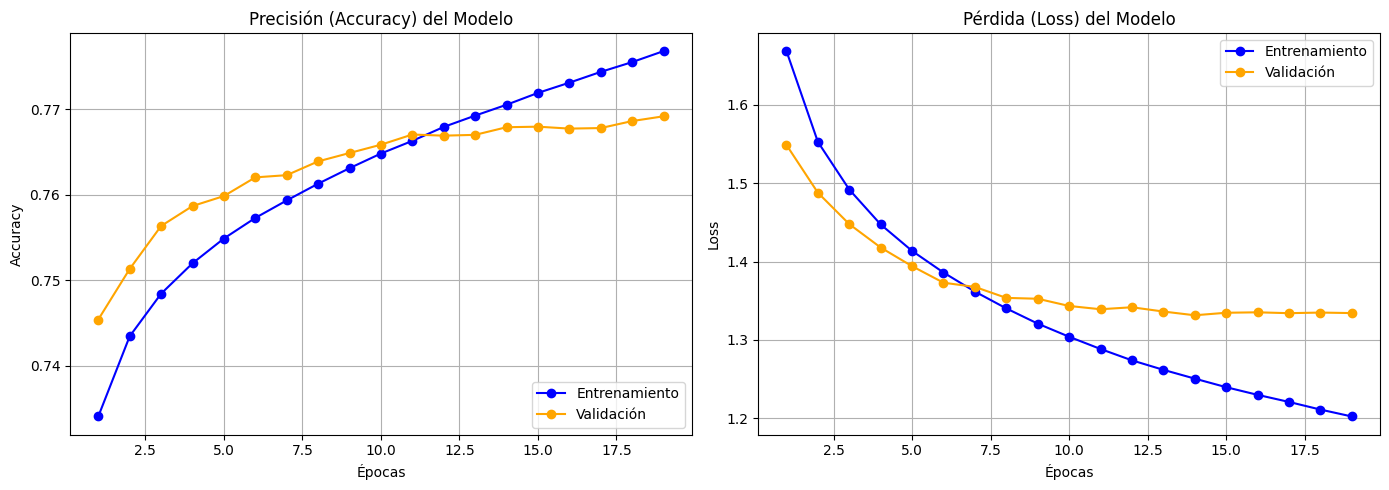

In [32]:
import matplotlib.pyplot as plt

def graficar_resultados(history):
    # Extraemos los valores del historial
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(1, len(acc) + 1)

    # Creamos la figura con dos subplots
    plt.figure(figsize=(14, 5))

    # Gráfico de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validación', color='orange', marker='o')
    plt.title('Precisión (Accuracy) del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Gráfico de Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento', color='blue', marker='o')
    plt.plot(epochs_range, val_loss, label='Validación', color='orange', marker='o')
    plt.title('Pérdida (Loss) del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Llamamos a la función con el historial de tu entrenamiento
# Asegúrate de usar la variable 'history_final' que generaste en el entrenamiento
graficar_resultados(history_final)

In [34]:
import numpy as np

def predict_response(input_text, model, tokenizer, max_len=39):
    # 1. Estandarizar y limpiar la entrada del usuario
    # (Asegúrate de aplicar la misma limpieza que usaste en el entrenamiento)
    input_text = input_text.lower().strip()
    
    # 2. Tokenizar y rellenar la secuencia del Encoder
    input_seq = tokenizer.texts_to_sequences([input_text])
    input_seq = tf.keras.preprocessing.sequence.pad_sequences(input_seq, maxlen=max_len, padding='post')
    
    # 3. Inicializar la secuencia del Decoder con el token de inicio
    # Modifica '<start>' si tu token de inicio se llamaba diferente (ej. '[start]')
    target_seq = np.zeros((1, max_len))
    target_seq[0, 0] = tokenizer.word_index.get('<start>', 1) 
    
    # 4. Bucle autoregresivo palabra por palabra
    for i in range(max_len - 1):
        # El modelo optimizado limpio recibe una lista con los inputs de [Encoder, Decoder]
        predicciones = model.predict([input_seq, target_seq], verbose=0)
        
        # Tomamos el token con mayor probabilidad (argmax) en la posición actual
        idx_palabra_predicha = np.argmax(predicciones[0, i, :])
        
        # Si el modelo predice el token de fin, rompemos el ciclo
        # Modifica '<end>' si tu token de fin se llamaba diferente
        if idx_palabra_predicha == tokenizer.word_index.get('<end>', 0) or idx_palabra_predicha == 0:
            break
            
        # Asignamos la palabra predicha a la siguiente posición del Decoder
        target_seq[0, i + 1] = idx_palabra_predicha

    # 5. Reconstruir el texto final quitando los índices vacíos
    palabras_respuesta = []
    for token_id in target_seq[0]:
        if token_id == 0:
            continue
        palabra = tokenizer.index_word.get(token_id, '')
        if palabra not in ['<start>', '<end>']:
            palabras_respuesta.append(palabra)
            
    return " ".join(palabras_respuesta)


def chat_con_transformer(model, tokenizer, max_len=39):
    print("--- CHAT CON TRANSFORMER OPTIMIZADO (Escribe 'salir' para terminar) ---")
    print("Inferencia activa. Recuerda que el modelo cargó los mejores pesos de la época 14.\n")
    
    while True:
        # 1. Pedir entrada al usuario
        usuario_input = input("\nUsuario: ")
        if usuario_input.lower() == 'salir':
            print("--- Chat finalizado ---")
            break

        if not usuario_input.strip():
            continue

        # 2. Generar respuesta usando la función predictiva adaptada
        respuesta = predict_response(usuario_input, model, tokenizer, max_len)

        # 3. Mostrar la salida del modelo
        print(f"Modelo : {respuesta}")

# Ejecutar la interfaz del chat interactivo
# Usamos directamente tu modelo de 20 millones de parámetros guardado en memoria
chat_con_transformer(modelo_transformer_optimizado_limpio, tokenizer)

--- CHAT CON TRANSFORMER OPTIMIZADO (Escribe 'salir' para terminar) ---
Inferencia activa. Recuerda que el modelo cargó los mejores pesos de la época 14.

Modelo : fine thanks
Modelo : i like spring
Modelo : i like spring and basketball
Modelo : i like spring and tea
Modelo : no i don't think so
Modelo : my name is john smith
Modelo : i usually go to the hospital
--- Chat finalizado ---


In [35]:
def chat_con_transformer(model, tokenizer, max_len=39):
    print("=========================================================")
    print("🤖 CHAT CON TRANSFORMER OPTIMIZADO")
    print("Escribe 'salir' para terminar la conversación.")
    print("=========================================================\n")
    
    while True:
        # 1. Pedir entrada al usuario (la cajita de texto)
        usuario_input = input("Escribe tu mensaje: ")
        
        # 2. Condición de salida
        if usuario_input.lower() == 'salir':
            print("\n👋 --- Chat finalizado ---")
            break

        # Evitar que el modelo colapse si envías un mensaje vacío
        if not usuario_input.strip():
            continue

        # 3. IMPRIMIR EXPLÍCITAMENTE LO QUE ESCRIBIÓ EL USUARIO
        print(f"\n👤 Usuario : {usuario_input}")

        # 4. Generar y mostrar la respuesta
        respuesta = predict_response(usuario_input, model, tokenizer, max_len)
        print(f"🤖 Modelo  : {respuesta}\n")
        print("-" * 50) # Línea separadora para que se lea mejor

# Ejecutar la interfaz
chat_con_transformer(modelo_transformer_optimizado_limpio, tokenizer)

🤖 CHAT CON TRANSFORMER OPTIMIZADO
Escribe 'salir' para terminar la conversación.


👤 Usuario : Hello
🤖 Modelo  : hi this is steven speaking

--------------------------------------------------

👤 Usuario : Do you like videogames, Steven?
🤖 Modelo  : yes i have a terrible headache

--------------------------------------------------

👤 Usuario : What is a headache?
🤖 Modelo  : it ’ s a long time

--------------------------------------------------

👋 --- Chat finalizado ---


En estos resultados se puede apreciar que el modelo ya no cae en el problema de el bucle repetitivo, lo cual significa una gran mejora con respecto al modelo optimizado anteriormente.

Con respecto a las respuestas en particular que da, en la primera el modelo es capaz de responder muy bien a la pregunta, ya que al preguntarle "cómo está?" este es capaz de responder con un "bien gracias". En la segunda pregunta, a pesar de que la respuesta no es del todo correcta, el modelo es capaz de construir una idea. En la tercera, al preguntarle si le gusta el café, este no responde si es que le gusta o no el café, pero responde señalando que tiene cierto tipo de comida, lo cual refleja que fue capaz de comprender que se le estaba preguntando por un consumible.

Estos resultados, aunque no llegan a la precisión necesaria para mantener una conversación fluida, evidencian un modelo capaz de comprender el contexto y sobre lo que se le está hablando, así como también uno que es capaz de explorar más allá e intentar dar respuestas algo más elaboradas y no responder solamente con un sí o un no.

### Data Augmentation

Luego de haber conseguido una estabilidad con el modelo gracias al Warmup, se llevará a cabo el Data Augmentation mediante Sustitución por Sinónimos. Al hacer esto, se forzará al modelo a aprender representaciones semánticas más profundas.

#### Importación de librerías

In [36]:
import numpy as np
import random
import nltk

# Descargamos las bases de datos de palabras (solo pesa unos pocos MBs)
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet

print("¡Dependencias descargadas correctamente!")

[nltk_data] Downloading package wordnet to /Users/naferyh/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/naferyh/nltk_data...


¡Dependencias descargadas correctamente!


#### Creación Función Core

In [37]:
def aumentar_oracion_por_sinonimos(oracion, probabilidad_reemplazo=0.2):
    """
    Toma una oración y reemplaza aleatoriamente algunas palabras por sinónimos.
    probabilidad_reemplazo: 0.2 significa que hay un 20% de chance de cambiar cada palabra.
    """
    palabras = oracion.split()
    nuevas_palabras = []
    
    for palabra in palabras:
        # 1. Proteger tokens especiales para no romper el Transformer
        if palabra in ['<start>', '<end>']:
            nuevas_palabras.append(palabra)
            continue
            
        # 2. Tirar los dados matemáticos
        if random.random() < probabilidad_reemplazo:
            # Buscar sinónimos en WordNet
            sinonimos = wordnet.synsets(palabra)
            if sinonimos:
                # Extraer las palabras de los sinónimos (lemas)
                lemas = sinonimos[0].lemma_names()
                # Filtrar para no usar la misma palabra exacta y limpiar guiones bajos
                lemas_validos = [lema.replace('_', ' ') for lema in lemas if lema.lower() != palabra.lower()]
                
                if lemas_validos:
                    # Elegir un sinónimo al azar y agregarlo
                    sinonimo_elegido = random.choice(lemas_validos)
                    nuevas_palabras.append(sinonimo_elegido)
                else:
                    nuevas_palabras.append(palabra)
            else:
                nuevas_palabras.append(palabra) # Si no hay sinónimo, dejamos la original
        else:
            nuevas_palabras.append(palabra) # Si no ganamos la probabilidad, dejamos la original
            
    return " ".join(nuevas_palabras)

print("¡Función Core creada!")

¡Función Core creada!


Antes de poder inyectar estos datos en el data set, se hará una prueba para ver cómo está funcionando este aumento.

In [38]:
# Hacemos una prueba con una probabilidad alta (50%) para forzar cambios visuales
oracion_prueba = "<start> i am very happy to see you my friend <end>"

print("Original :", oracion_prueba)
print("Aumento 1:", aumentar_oracion_por_sinonimos(oracion_prueba, probabilidad_reemplazo=0.5))
print("Aumento 2:", aumentar_oracion_por_sinonimos(oracion_prueba, probabilidad_reemplazo=0.5))
print("Aumento 3:", aumentar_oracion_por_sinonimos(oracion_prueba, probabilidad_reemplazo=0.5))

Original : <start> i am very happy to see you my friend <end>
Aumento 1: <start> i americium very happy to see you my friend <end>
Aumento 2: <start> iodin am very happy to see you my friend <end>
Aumento 3: <start> iodine am very happy to see you my friend <end>


Se puede ver que de momento que las nuevas variaciones de frases son bastante incoherentes y no tienen sentido, es por esto que primero se deberá trabajar en el data augmentation para luego poder integrar los datos nuevos.

In [39]:
import numpy as np
import random
import nltk

# Descargamos WordNet y la lista de Stop Words
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import wordnet
from nltk.corpus import stopwords

# Cargamos las palabras que NO debemos tocar
stop_words = set(stopwords.words('english'))

print("¡Dependencias descargadas correctamente!")

[nltk_data] Downloading package wordnet to /Users/naferyh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/naferyh/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/naferyh/nltk_data...


¡Dependencias descargadas correctamente!


[nltk_data]   Unzipping corpora/stopwords.zip.


In [40]:
def aumentar_oracion_por_sinonimos_v2(oracion, probabilidad_reemplazo=0.2):
    palabras = oracion.split()
    nuevas_palabras = []
    
    for palabra in palabras:
        palabra_limpia = palabra.lower()
        
        # 1. Proteger tokens especiales, palabras cortas y stop words
        if palabra_limpia in ['<start>', '<end>'] or palabra_limpia in stop_words or len(palabra_limpia) < 3:
            nuevas_palabras.append(palabra)
            continue
            
        # 2. Tirar los dados matemáticos
        if random.random() < probabilidad_reemplazo:
            sinonimos = wordnet.synsets(palabra_limpia)
            if sinonimos:
                lemas = sinonimos[0].lemma_names()
                lemas_validos = [lema.replace('_', ' ') for lema in lemas if lema.lower() != palabra_limpia]
                
                if lemas_validos:
                    # Elegimos el sinónimo, pero mantenemos si era mayúscula/minúscula
                    sinonimo_elegido = random.choice(lemas_validos)
                    if palabra.istitle():
                        sinonimo_elegido = sinonimo_elegido.capitalize()
                    nuevas_palabras.append(sinonimo_elegido)
                else:
                    nuevas_palabras.append(palabra)
            else:
                nuevas_palabras.append(palabra)
        else:
            nuevas_palabras.append(palabra)
            
    return " ".join(nuevas_palabras)

print("¡Función Core v2 creada y protegida contra el Americio!")

¡Función Core v2 creada y protegida contra el Americio!


In [41]:
oracion_prueba = "<start> i am very happy to see you my friend <end>"

print("Original :", oracion_prueba)
for i in range(3):
    print(f"Aumento {i+1}:", aumentar_oracion_por_sinonimos_v2(oracion_prueba, probabilidad_reemplazo=0.5))

Original : <start> i am very happy to see you my friend <end>
Aumento 1: <start> i am very happy to see you my friend <end>
Aumento 2: <start> i am very happy to see you my friend <end>
Aumento 3: <start> i am very happy to see you my friend <end>


In [42]:
def aumentar_oracion_por_sinonimos_v3(oracion, probabilidad_reemplazo=0.4):
    palabras = oracion.split()
    nuevas_palabras = []
    
    for palabra in palabras:
        palabra_limpia = palabra.lower()
        
        # 1. Filtros de seguridad (Tokens, Stop Words y palabras cortas)
        if palabra_limpia in ['<start>', '<end>'] or palabra_limpia in stop_words or len(palabra_limpia) < 3:
            nuevas_palabras.append(palabra)
            continue
            
        # 2. Dados de probabilidad
        if random.random() < probabilidad_reemplazo:
            sinonimos = wordnet.synsets(palabra_limpia)
            lemas_totales = set() # Usamos un set para no tener sinónimos repetidos
            
            # EL ARREGLO: Recorremos TODOS los significados de la palabra
            for syn in sinonimos:
                for lema in syn.lemma_names():
                    lema_texto = lema.replace('_', ' ').lower()
                    # Solo guardamos si es distinto a la palabra original
                    if lema_texto != palabra_limpia:
                        lemas_totales.add(lema_texto)
            
            lemas_validos = list(lemas_totales)
            
            if lemas_validos:
                sinonimo_elegido = random.choice(lemas_validos)
                # Mantenemos las mayúsculas si la original la tenía
                if palabra.istitle():
                    sinonimo_elegido = sinonimo_elegido.capitalize()
                nuevas_palabras.append(sinonimo_elegido)
            else:
                nuevas_palabras.append(palabra) # No encontramos sinónimos válidos
        else:
            nuevas_palabras.append(palabra) # No ganamos el % de probabilidad
            
    return " ".join(nuevas_palabras)

print("¡Función V3 creada: Búsqueda profunda de sinónimos activada!")

¡Función V3 creada: Búsqueda profunda de sinónimos activada!


In [43]:
# Usamos una probabilidad del 50% para ver la acción
oracion_prueba = "<start> i am very happy to see you my friend <end>"

print("Original :", oracion_prueba)
for i in range(5):
    print(f"Aumento {i+1}:", aumentar_oracion_por_sinonimos_v3(oracion_prueba, probabilidad_reemplazo=0.5))

Original : <start> i am very happy to see you my friend <end>
Aumento 1: <start> i am very glad to visit you my champion <end>
Aumento 2: <start> i am very happy to see you my acquaintance <end>
Aumento 3: <start> i am very felicitous to ensure you my friend <end>
Aumento 4: <start> i am very felicitous to see you my quaker <end>
Aumento 5: <start> i am very happy to see you my ally <end>


In [44]:
# Prueba Unitaria 2: Oración con adjetivos y sustantivos fuertes
oracion_prueba_2 = "<start> i think this movie is really awesome and very funny <end>"

print("Original :", oracion_prueba_2)
print("-" * 60)

for i in range(5):
    # Usamos probabilidad_reemplazo=0.6 para forzar más cambios
    resultado = aumentar_oracion_por_sinonimos_v3(oracion_prueba_2, probabilidad_reemplazo=0.6)
    print(f"Aumento {i+1}: {resultado}")

Original : <start> i think this movie is really awesome and very funny <end>
------------------------------------------------------------
Aumento 1: <start> i think this motion picture is very awful and very rum <end>
Aumento 2: <start> i remember this picture show is really awing and very suspect <end>
Aumento 3: <start> i opine this flick is real awe-inspiring and very fishy <end>
Aumento 4: <start> i imagine this pic is actually awful and very good story <end>
Aumento 5: <start> i think this movie is genuinely awe-inspiring and very curious <end>


In [46]:
import tensorflow as tf

print("📚 Entrenando al Tokenizer con el nuevo vocabulario expandido...")

# 1. Creamos un nuevo Tokenizer limpio
tokenizer_aug = tf.keras.preprocessing.text.Tokenizer(filters='')

# 2. Le pasamos TODO el texto (preguntas y respuestas originales + aumentadas)
# Asegúrate de que las variables train_inputs_aug y train_targets_aug existan
tokenizer_aug.fit_on_texts(train_inputs_aug + train_targets_aug)

# 3. Calculamos el nuevo tamaño de vocabulario
vocab_size_aug = len(tokenizer_aug.word_index) + 1
print(f"✅ Nuevo tamaño de vocabulario: {vocab_size_aug} palabras.")

📚 Entrenando al Tokenizer con el nuevo vocabulario expandido...


NameError: name 'train_inputs_aug' is not defined

In [45]:
import tensorflow as tf
import numpy as np

print("🔄 Convirtiendo el texto aumentado a secuencias numéricas...")

# 1. Definimos el largo máximo de las oraciones (el mismo que usabas en tu código original)
max_len = 39 

# 2. Convertimos los textos a secuencias de números usando el NUEVO tokenizer
encoder_seqs = tokenizer_aug.texts_to_sequences(train_inputs_aug)
decoder_seqs = tokenizer_aug.texts_to_sequences(train_targets_aug)

# 3. Aplicamos Padding (relleno de ceros) al Encoder
encoder_input_data = tf.keras.preprocessing.sequence.pad_sequences(
    encoder_seqs, maxlen=max_len, padding='post'
)

# 4. Aplicamos Padding al Decoder (le damos max_len + 1 temporalmente para hacer el desfase)
decoder_secuencias_padded = tf.keras.preprocessing.sequence.pad_sequences(
    decoder_seqs, maxlen=max_len + 1, padding='post'
)

# 5. Aplicamos "Teacher Forcing" (Desfase de 1 posición entre input y target)
# decoder_input_data: Toma todas las palabras desde el principio, ignorando la última
decoder_input_data = decoder_secuencias_padded[:, :-1]

# target_data: Toma todas las palabras desde la segunda, ignorando la primera (<start>)
target_data = decoder_secuencias_padded[:, 1:]

print(f"✅ Matrices listas para entrenar:")
print(f"   - Tamaño de encoder_input_data: {encoder_input_data.shape}")
print(f"   - Tamaño de decoder_input_data: {decoder_input_data.shape}")
print(f"   - Tamaño de target_data:        {target_data.shape}")

🔄 Convirtiendo el texto aumentado a secuencias numéricas...


NameError: name 'tokenizer_aug' is not defined

## Conclusiones

En este proyecto se han implementado, optimizado y contrastado dos de los paradigmas más importantes en el Procesamiento de Lenguaje Natural: Las RNN (LSTM) y los Transformer. En este experimento se concluyó lo siguiente:

1. El límite de la recurrencia (LSTM):
Las arquitecturas tradicionales como el LSTM representaron un avance para resolver el problema del desvanecimiento del gradiente en redes RNN simples. A pesar de ello, el LSTM entrenado evidenció sus limitaciones:

* Al procesar la información palabra por palabra, la memoria a largose diluye.
* En la fase de inferencia, el modelo tendía a generar bucles repetitivos.
* La red LSTM tenía margen de mejora con la implementación de un Early Stopping para evitar que esta comenzara a memorizar.

2. Procesamiento paralelo (Transformer Base):
El modelo Transformer demostró ser superior tanto técnica como cualitativamente, con lo cual validó por qué es el estándar actual en IA Generativa.

* A diferencia del LSTM, el transformer procesó toda la secuencia de manera simultánea. Su mecanismo le permitió ponderar la importancia de todas las palabras de la oración, dándole así un contexto global más rico.
* Este modelo logró un punto de equilibrio perfecto, alcanzando una convergencia estable del 76,7% de validación y obteniendo puntuaciones robustas en métricas de texto libre (BLEU y ROUGE-L), generando diálogos coherentes y lógicos.

3. El impacto de los Hiperparámetros:
La experimentación avanzada al incrementar la capacidad del transformer tuvo resultados bastante sorprendentes. A pesar de que la red demostró tener una capacidad de absorsión masiva, demostró un principio clave del Deep Learning: un modelo sobredimensionado frente a un volumen de datos acotado colapsa.

* El Early Stopping actuó de manera correcta al detener el entrenamiento para evitar que el modelo memorizara, pero al hacer esto, el modelo no tuvo el suficiente entrenamiento para aprender contextos.
* Debido a esto la red encontró un atajo estadístico para minimizar su error al responder "i'm sorry" a cualquier pregunta sin importar el contexto.

Al tener todo esto en consideración, se concluye que el éxito de un modelo depende de un balance entre su arquitectura y sus datos. El Transformer supera a las redes recurrentes al eliminar la barrera de la memoria secuencial y permitir la paralelización masiva.